In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

print(df.head())

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [3]:
data = df['Passengers'].values.reshape(-1,1)

In [4]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data)


In [5]:
def create_dataset(dataset, time_step=5):
    X, y = [], []

    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])

    return np.array(X), np.array(y)

time_step = 5

X, y = create_dataset(data, time_step)

In [6]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]

In [7]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [8]:
model = Sequential()

model.add(LSTM(50, activation='tanh',
               input_shape=(time_step,1)))

model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16
)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0855 - val_loss: 0.2745
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0419 - val_loss: 0.1393
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0172 - val_loss: 0.0578
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0134 - val_loss: 0.0309
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0140 - val_loss: 0.0324
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0112 - val_loss: 0.0403
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0101 - val_loss: 0.0448
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0099 - val_loss: 0.0413
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0090 - val_loss: 0.0348
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0085 - val_loss: 0.0311
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0083 - val_loss: 0.0304
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0080 - val_loss: 0.0305
E

In [11]:
train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [12]:
train_pred = scaler.inverse_transform(train_pred)
test_pred  = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual  = scaler.inverse_transform(y_test.reshape(-1,1))

In [13]:
train_rmse = sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse  = sqrt(mean_squared_error(y_test_actual, test_pred))

print("Train RMSE =", train_rmse)
print("Test RMSE =", test_rmse)

Train RMSE = 40.40085507588009
Test RMSE = 80.76694978606713


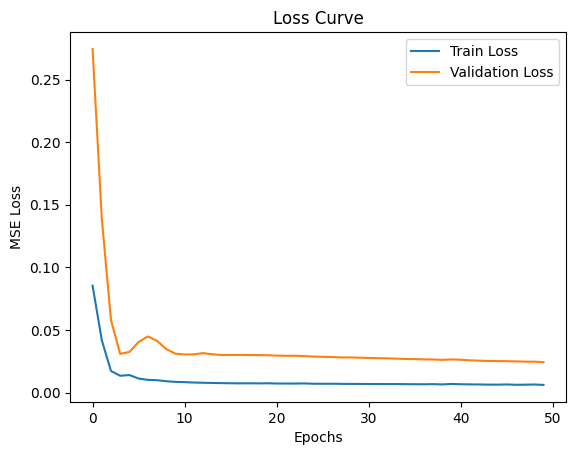

In [14]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

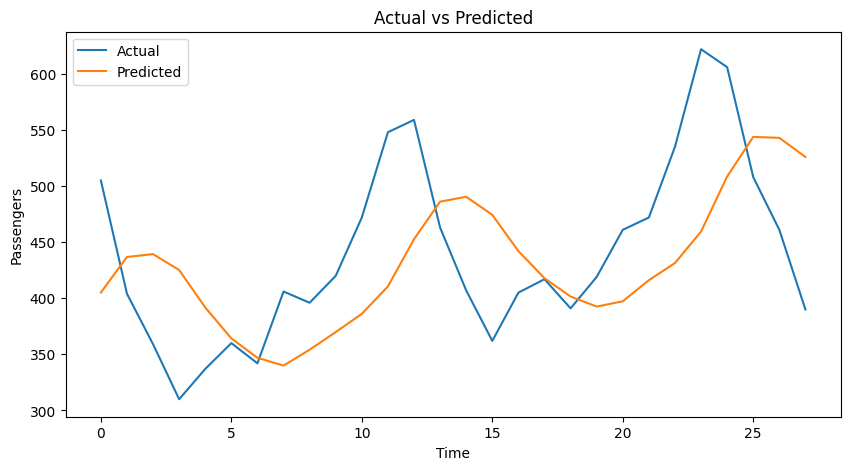

1. Larger sequence length captures more past data.
2. Too large sequence length may slow training.
3. LSTM solves vanishing gradient better than simple RNN.
4. Lower RMSE means better prediction.
5. Adam optimizer gives faster convergence.


In [15]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label="Actual")
plt.plot(test_pred, label="Predicted")

plt.title("Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.legend()
plt.show()

print("1. Larger sequence length captures more past data.")
print("2. Too large sequence length may slow training.")
print("3. LSTM solves vanishing gradient better than simple RNN.")
print("4. Lower RMSE means better prediction.")
print("5. Adam optimizer gives faster convergence.")